In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.optimizers import Adam
import keras
from keras.models import Sequential, Model
from keras.layers import *
from keras.utils import Sequence
from keras.layers import Conv2D, MaxPooling2D
from qkeras import *

from keras.utils import Sequence
from keras.callbacks import CSVLogger
from keras.callbacks import EarlyStopping

import os
import random
from datetime import datetime
import time

import matplotlib.pyplot as plt

pi = 3.14159265359
maxval=1e9
minval=1e-9

2025-12-01 23:47:08.239939: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-01 23:47:08.240014: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-01 23:47:08.241141: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-01 23:47:08.248164: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-01 23:47:19.679496: W tensorflow/compiler/tf2

In [2]:
# # os.chdir('SmartPix/data_generator')
os.chdir('/home/das214/SmartPix/SoftQuantize')
!pwd

FileNotFoundError: [Errno 2] No such file or directory: '/home/das214/SmartPix/SoftQuantize'

In [3]:
from DG.OptimizedDataGenerator_v2 import OptimizedDataGenerator
from losses.loss import custom_loss
from models.SoftQuantizeLayer import SoftQuantizeLayer
from models.AnnealingScheduler import AnnealingScheduler
from models.models import CreateModel # Conv2D model

In [ ]:
# import keras
# from keras.layers import *
# from keras.models import Sequential, Model
# from keras.utils import Sequence
# from qkeras import *

# import tensorflow as tf
# from tensorflow.keras import datasets, layers, models

# def var_network(var, hidden=10, output=2):
#     var = Flatten()(var)
#     var = QDense(
#         hidden,
#         kernel_quantizer=quantized_bits(8, 0, alpha=1),
#         bias_quantizer=quantized_bits(8, 0, alpha=1),
#         kernel_regularizer=tf.keras.regularizers.L1L2(0.01),
#         activity_regularizer=tf.keras.regularizers.L2(0.01),
#     )(var)
#     var = QActivation("quantized_tanh(8, 0, 1)")(var)
#     var = QDense(
#         hidden,
#         kernel_quantizer=quantized_bits(8, 0, alpha=1),
#         bias_quantizer=quantized_bits(8, 0, alpha=1),
#         kernel_regularizer=tf.keras.regularizers.L1L2(0.01),
#         activity_regularizer=tf.keras.regularizers.L2(0.01),
#     )(var)
#     var = QActivation("quantized_tanh(8, 0, 1)")(var)
#     return QDense(
#         output,
#         kernel_quantizer=quantized_bits(8, 0, alpha=1),
#         bias_quantizer=quantized_bits(8, 0, alpha=1),
#         kernel_regularizer=tf.keras.regularizers.L1L2(0.01),
#     )(var)

# def conv_network(var, n_filters=5, kernel_size=3):
#     var = QSeparableConv2D(
#         n_filters,kernel_size,
#         depthwise_quantizer=quantized_bits(4, 0, 1, alpha=1),
#         pointwise_quantizer=quantized_bits(4, 0, 1, alpha=1),
#         bias_quantizer=quantized_bits(4, 0, alpha=1),
#         depthwise_regularizer=tf.keras.regularizers.L1L2(0.01),
#         pointwise_regularizer=tf.keras.regularizers.L1L2(0.01),
#         activity_regularizer=tf.keras.regularizers.L2(0.01),
#     )(var)
#     var = QActivation("quantized_tanh(4, 0, 1)")(var)
#     var = QConv2D(
#         n_filters,1,
#         kernel_quantizer=quantized_bits(4, 0, alpha=1),
#         bias_quantizer=quantized_bits(4, 0, alpha=1),
#         kernel_regularizer=tf.keras.regularizers.L1L2(0.01),
#         activity_regularizer=tf.keras.regularizers.L2(0.01),
#     )(var)
#     var = QActivation("quantized_tanh(4, 0, 1)")(var)    
#     return var

# def CreateModel(shape, output, n_filters, pool_size):
#     x_base = x_in = Input(shape)
#     x_base = SoftQuantizeLayer(
#         n_bits=2,                     
#         initial_range=[-1.0, 1.0],    
#         trainable_levels=False,        
#         trainable_thresholds=True,          
#         initial_k=1.0,                
#         trainable_k=True,             
#         name='soft_quantizer_output'  
#     )(x_base)

#     stack = conv_network(x_base)
#     stack = AveragePooling2D(
#         pool_size=(pool_size, pool_size), 
#         strides=None, 
#         padding="valid", 
#         data_format=None,        
#     )(stack)
#     stack = QActivation("quantized_bits(8, 0, alpha=1)")(stack)
#     stack = var_network(stack, hidden=16, output=output)
#     model = Model(inputs=x_in, outputs=stack)
#     return model

In [3]:
os.listdir('/work/projects/preamp_response/')

PermissionError: [Errno 13] Permission denied: '/depot/cms/users/das214/datasets/temporary/preamp_response/'

In [4]:
# dataset_base_dir = "/depot/cms/users/das214/datasets/dataset_3sr/dataset_3sr_16x16_50x12P5_parquets/contained"
dataset_base_dir = '/depot/cms/users/das214/datasets/temporary/preamp_response/'
tfrecords_base_dir = os.path.join(dataset_base_dir, "TFR_files", "2t")

dataset_train_dir = os.path.join(dataset_base_dir, "train")
dataset_test_dir = os.path.join(dataset_base_dir, "test")
tfrecords_dir_train = os.path.join(tfrecords_base_dir, "TFR_train")
tfrecords_dir_val   = os.path.join(tfrecords_base_dir, "TFR_val")

batch_size = 5000
val_batch_size = 5000
train_file_size = len(os.listdir(dataset_train_dir))
val_file_size = len(os.listdir(dataset_test_dir))

PermissionError: [Errno 13] Permission denied: '/depot/cms/users/das214/datasets/temporary/preamp_response/train'

In [6]:
# start_time = time.time()
# validation_generator = OptimizedDataGenerator(
#     dataset_base_dir = dataset_test_dir,
#     file_type = "parquet",
#     data_format = "3D",
#     batch_size = val_batch_size,
#     # optimize_batch_size = True,
#     file_count = val_file_size,
#     to_standardize= True,
#     labels_list = ['x-midplane','y-midplane','cotAlpha','cotBeta'],
#     input_shape = (2,13,21), # (20,13,21),
#     transpose = (0,2,3,1),
#     shuffle = False, 
#     files_from_end=True,

#     tfrecords_dir = tfrecords_dir_val,
#     use_time_stamps = [5,20],
#     max_workers = 2
# )

# print("--- Validation generator %s seconds ---" % (time.time() - start_time))

# # training generator
# start_time = time.time()
# training_generator = OptimizedDataGenerator(
#     dataset_base_dir = dataset_train_dir,
#     file_type = "parquet",
#     data_format = "3D",
#     batch_size = batch_size,
#     # optimize_batch_size = True,
#     file_count = train_file_size,
#     to_standardize= True,
#     labels_list = ['x-midplane','y-midplane','cotAlpha','cotBeta'],
#     input_shape = (2,13,21), # (20,13,21),
#     transpose = (0,2,3,1),
#     shuffle = False, # True 

#     tfrecords_dir = tfrecords_dir_train,
#     use_time_stamps = [5, 20],
#     max_workers = 2
# )
# print("--- Training generator %s seconds ---" % (time.time() - start_time))

Processing Files...: 100%|██████████| 20/20 [00:06<00:00,  3.31it/s]


Directory /depot/cms/users/das214/datasets/temporary/preamp_response/TFR_files/2t/TFR_val does not exist and cannot be removed.


Saving batches as TFRecords: 100%|██████████| 16/16 [00:14<00:00,  1.11it/s]


Metadata saved successfully ast /depot/cms/users/das214/datasets/temporary/preamp_response/TFR_files/2t/TFR_val/metadata.json
Loading metadata from /depot/cms/users/das214/datasets/temporary/preamp_response/TFR_files/2t/TFR_val/metadata.json
--- Validation generator 20.76019811630249 seconds ---


Processing Files...: 100%|██████████| 80/80 [00:24<00:00,  3.30it/s]


Directory /depot/cms/users/das214/datasets/temporary/preamp_response/TFR_files/2t/TFR_train does not exist and cannot be removed.


Saving batches as TFRecords: 100%|██████████| 64/64 [00:39<00:00,  1.60it/s]


Metadata saved successfully ast /depot/cms/users/das214/datasets/temporary/preamp_response/TFR_files/2t/TFR_train/metadata.json
Loading metadata from /depot/cms/users/das214/datasets/temporary/preamp_response/TFR_files/2t/TFR_train/metadata.json


--- Training generator 64.66978859901428 seconds ---


In [7]:
# Loading pre-generated TFRecords
validation_generator = OptimizedDataGenerator(
    load_from_tfrecords_dir= tfrecords_dir_val,
    shuffle=True,
    seed=42,
    quantize=False,
)

training_generator = OptimizedDataGenerator(
    load_from_tfrecords_dir = tfrecords_dir_train,
    shuffle=True,
    seed=42,
    quantize=False,
)


Loading metadata from /depot/cms/users/das214/datasets/temporary/preamp_response/TFR_files/2t/TFR_val/metadata.json
Loading metadata from /depot/cms/users/das214/datasets/temporary/preamp_response/TFR_files/2t/TFR_train/metadata.json


In [12]:
model=CreateModel(shape = (13,21,2), output = 14, n_filters=5,pool_size=3)
model.compile(
    optimizer=tf.keras.optimizers.Nadam(learning_rate=1e-3, clipnorm=1.0),
    loss=custom_loss,
)

model.summary()

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 13, 21, 2)]       0         
                                                                 
 q_separable_conv2d_3 (QSep  (None, 11, 19, 5)         33        
 arableConv2D)                                                   
                                                                 
 q_activation_15 (QActivati  (None, 11, 19, 5)         0         
 on)                                                             
                                                                 
 q_conv2d_3 (QConv2D)        (None, 11, 19, 5)         30        
                                                                 
 q_activation_16 (QActivati  (None, 11, 19, 5)         0         
 on)                                                             
                                                           

In [13]:
from datetime import datetime

fingerprint = '%08x' % random.randrange(16**8)
timestamp = datetime.now().strftime('%Y%m%d-%H%M%S')
os.makedirs("trained_models", exist_ok=True)
base_dir = f'./trained_models/model-{fingerprint}-checkpoints'

checkpoints_dir = os.path.join(base_dir, 'checkpoints')

os.makedirs(base_dir, exist_ok=True)
os.makedirs(checkpoints_dir, exist_ok=True) 
checkpoint_filepath = os.path.join(checkpoints_dir, 'weights.{epoch:02d}-t{loss:.2f}-v{val_loss:.2f}.hdf5')

In [14]:
checkpoint_filepath

'./trained_models/model-c6103ed3-checkpoints/checkpoints/weights.{epoch:02d}-t{loss:.2f}-v{val_loss:.2f}.hdf5'

In [15]:
# 9f5e5c2c : 1000 epochs
print(fingerprint)

c6103ed3


In [16]:
from tensorflow.keras.callbacks import CSVLogger, EarlyStopping, ModelCheckpoint, Callback
import csv

early_stopping_patience = 50
es = EarlyStopping(patience=early_stopping_patience, restore_best_weights=True)

mcp = ModelCheckpoint(
        filepath=checkpoint_filepath,
        save_weights_only=True,
       save_freq='epoch'
)

class SoftQuantizeLoggerCallback(Callback):
    def __init__(self, log_filepath, layer_name="soft_quantizer_output"):
        super().__init__()
        self.log_filepath = log_filepath
        self.layer_name = layer_name
        self.header_written = False

    def on_train_begin(self, logs=None):
        os.makedirs(os.path.dirname(self.log_filepath), exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        try:
            layer = self.model.get_layer(self.layer_name)
            if not hasattr(layer, 'n_bits'):
                 print(f"\nWarning: Layer '{self.layer_name}' is not a SoftQuantizeLayer. Skipping logging.")
                 return
        except ValueError:
            print(f"\nWarning: Layer '{self.layer_name}' not found in the model. Skipping logging.")
            return

        if not self.header_written:
            num_levels = layer.num_levels
            num_thresholds = num_levels - 1
            
            header = ['epoch', 'k']
            header.extend([f'level_{i}' for i in range(num_levels)])
            header.extend([f'threshold_{i}' for i in range(num_thresholds)])

            header.append('raw_first_level')
            header.extend([f'raw_log_level_delta_{i}' for i in range(num_levels - 1)])
            header.append('raw_first_threshold')
            if hasattr(layer, 'log_threshold_deltas'):
                header.extend([f'raw_log_threshold_delta_{i}' for i in range(num_thresholds - 1)])

            with open(self.log_filepath, mode='w', newline='') as f:
                writer = csv.writer(f)
                writer.writerow(header)
            self.header_written = True

        k_val = layer.k.numpy().item()
        levels = layer.levels.numpy().tolist()
        thresholds = layer.thresholds.numpy().tolist()
        
        first_level = layer.first_level.numpy().item()
        log_level_deltas = layer.log_level_deltas.numpy().tolist()
        first_threshold = layer.first_threshold.numpy().item()
        
        row_data = [epoch, k_val]
        row_data.extend(levels)
        row_data.extend(thresholds)
        row_data.append(first_level)
        row_data.extend(log_level_deltas)
        row_data.append(first_threshold)
        
        if hasattr(layer, 'log_threshold_deltas'):
            log_threshold_deltas = layer.log_threshold_deltas.numpy().tolist()
            row_data.extend(log_threshold_deltas)
        
        with open(self.log_filepath, mode='a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(row_data)


csv_logger = CSVLogger(f'{base_dir}/training_log.csv', append=True)
scheduler_callback = AnnealingScheduler(
    schedule='cosine',  
    target_layer_name='soft_quantizer_output', 
    initial_k=1.0,
    final_k=67.0, 
    verbose=1      
)

quantizer_logger = SoftQuantizeLoggerCallback(
    log_filepath=f"{base_dir}/soft_quantizer_state_log.csv", # New, more descriptive filename
    layer_name="soft_quantizer_output"
)


In [ ]:
history = model.fit(
        x=training_generator,
        validation_data=validation_generator,
        # callbacks=[mcp, csv_logger, scheduler_callback, quantizer_logger],
        callbacks=[mcp, csv_logger],
        epochs=1000,
        shuffle=False,
        verbose=1
    )

Epoch 1/1000


2025-11-18 23:45:34.417125: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2025-11-18 23:45:34.918478: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-11-18 23:45:35.957416: I tensorflow/core/util/cuda_solvers.cc:179] Creating GpuSolver handles for stream 0x564d063e2820
2025-11-18 23:45:38.005189: I external/local_xla/xla/service/service.cc:168] XLA service 0x7fa15db1c2f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-18 23:45:38.005254: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100-PCIE-40GB MIG 7g.40gb, Compute Capability 8.0
2025-11-18 23:45:38.284617: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1763505938.842280 1280334 device_compiler.h:186] Compile

64/64 [==============================] - 18s 112ms/step - loss: 42945.0312 - val_loss: 14258.1328
Epoch 2/1000
64/64 [==============================] - 6s 92ms/step - loss: 11570.5420 - val_loss: 10058.9531
Epoch 3/1000
64/64 [==============================] - 6s 93ms/step - loss: 8895.4893 - val_loss: 7737.2378
Epoch 4/1000
64/64 [==============================] - 6s 94ms/step - loss: 6025.3242 - val_loss: 5006.6636
Epoch 5/1000
64/64 [==============================] - 6s 93ms/step - loss: 4120.0532 - val_loss: 3848.4451
Epoch 6/1000
64/64 [==============================] - 6s 89ms/step - loss: 3108.9773 - val_loss: 3143.0298
Epoch 7/1000
64/64 [==============================] - 6s 91ms/step - loss: 2401.6587 - val_loss: 2615.6489
Epoch 8/1000
64/64 [==============================] - 6s 94ms/step - loss: 2182.2820 - val_loss: 2682.8506
Epoch 9/1000
64/64 [==============================] - 6s 92ms/step - loss: 1897.3402 - val_loss: 1790.1234
Epoch 10/1000
64/64 [=======================

In [26]:
print(history.history.keys())
print(history.history['loss'][:5])
print(history.history['val_loss'][:5])


dict_keys(['loss', 'val_loss'])
[42945.03125, 11570.5419921875, 8895.4892578125, 6025.32421875, 4120.05322265625]
[14258.1328125, 10058.953125, 7737.23779296875, 5006.66357421875, 3848.445068359375]


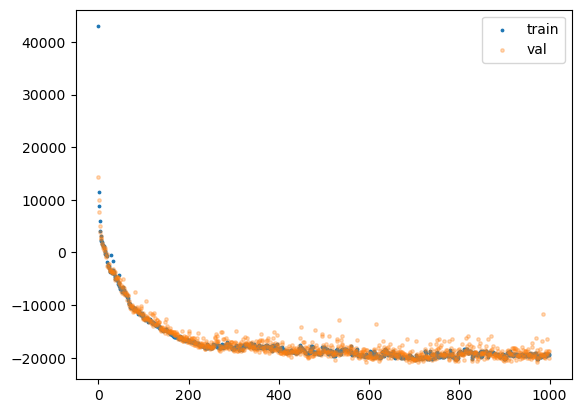

In [33]:
import matplotlib.pyplot as plt

epochs_vals = range(1000)
plt.scatter(epochs_vals, history.history['loss'], label='train', alpha = 1.0, s = 3)
plt.scatter(epochs_vals, history.history['val_loss'], label='val', alpha = 0.3, s = 6)
plt.legend()
plt.show()


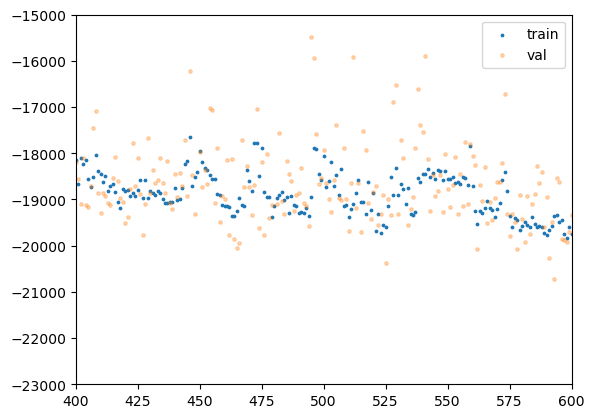

In [36]:
import matplotlib.pyplot as plt

epochs_vals = range(1000)
plt.scatter(epochs_vals, history.history['loss'], label='train', alpha = 1.0, s = 3)
plt.scatter(epochs_vals, history.history['val_loss'], label='val', alpha = 0.3, s = 6)
plt.legend()
plt.xlim([400, 600])
plt.ylim([-23_000, -15_000])
plt.show()
